In [1]:
#TRAINING RF MODEL & PREDICTION, PRINTING CONFUSION MATRIX, F1-SCORE, IMPORTANT FEATURES
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, f1_score
import pandas as pd

# 1. Load the dataset
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

# 2. Split into Training and Testing sets (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Train the Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# 4. Predictions
y_pred = rf_model.predict(X_test)

# 5. Evaluation
conf_matrix = confusion_matrix(y_test, y_pred)
f1_macro = f1_score(y_test, y_pred, average='macro')

print("Confusion Matrix:")
print(conf_matrix)
print(f"\nMacro-Average F1 Score: {f1_macro:.4f}")

# 6. Feature Importance
importances = pd.Series(rf_model.feature_importances_, index=data.feature_names)
print("\nTop 5 Most Important Features:")
print(importances.sort_values(ascending=False).head(5))

Confusion Matrix:
[[40  3]
 [ 1 70]]

Macro-Average F1 Score: 0.9623

Top 5 Most Important Features:
worst area              0.153892
worst concave points    0.144663
mean concave points     0.106210
worst radius            0.077987
mean concavity          0.068001
dtype: float64


--- MODEL PERFORMANCE TABLE ---
              precision  recall  f1-score  support
malignant         0.976   0.930     0.952   43.000
benign            0.959   0.986     0.972   71.000
accuracy          0.965   0.965     0.965    0.965
macro avg         0.967   0.958     0.962  114.000
weighted avg      0.965   0.965     0.965  114.000


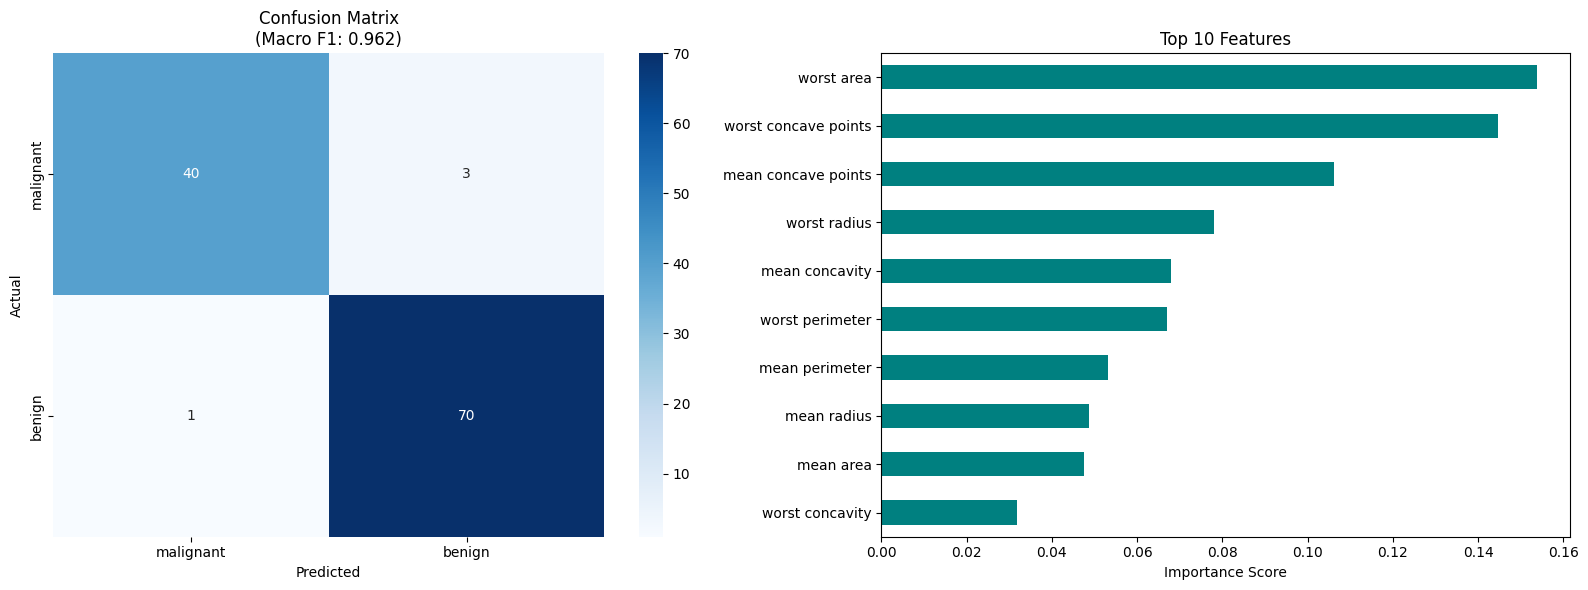

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# 1. Load and Split
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Train Model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# 3. Predict & Generate Report
y_pred = rf_model.predict(X_test)
# Convert classification report to a DataFrame for a tabular look
report_dict = classification_report(y_test, y_pred, target_names=data.target_names, output_dict=True)
report_df = pd.DataFrame(report_dict).transpose()

# 4. Display the Metrics Table
print("--- MODEL PERFORMANCE TABLE ---")
print(report_df.round(3)) 

# 5. Visualizing the Results (2 Subplots)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Subplot 1: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=data.target_names, yticklabels=data.target_names, ax=ax1)
ax1.set_title(f"Confusion Matrix\n(Macro F1: {report_dict['macro avg']['f1-score']:.3f})")
ax1.set_ylabel('Actual')
ax1.set_xlabel('Predicted')

# Subplot 2: Top 10 Features
importances = pd.Series(rf_model.feature_importances_, index=data.feature_names).sort_values(ascending=False)
importances.head(10).plot(kind='barh', color='teal', ax=ax2).invert_yaxis()
ax2.set_title('Top 10 Features')
ax2.set_xlabel('Importance Score')

plt.tight_layout()
plt.show()

In [31]:
# 6. Random Patient Prediction
random_idx = np.random.randint(0, len(X_test))
sample_patient = X_test.iloc[random_idx : random_idx + 1] # DataFrame slice avoids warnings
actual_val = y_test[random_idx]

# Predict
pred_val = rf_model.predict(sample_patient)[0]
prob = rf_model.predict_proba(sample_patient)[0]

# Display as a Table
print(f"\n--- RANDOM DIAGNOSTIC TEST (Patient Index: {random_idx}) ---")
result_data = {
    "Attribute": ["Predicted Diagnosis", "Actual Diagnosis", "Confidence Score"],
    "Result": [
        data.target_names[pred_val].upper(),
        data.target_names[actual_val].upper(),
        f"{max(prob)*100:.2f}%"
    ]
}
result_df = pd.DataFrame(result_data)
result_df.style.set_properties(**{'text-align': 'left'})\
               .set_table_styles([dict(selector='th', props=[('text-align', 'left')])])\
               .hide(axis='index') # Hides the index numbers on the left


--- RANDOM DIAGNOSTIC TEST (Patient Index: 42) ---


Attribute,Result
Predicted Diagnosis,BENIGN
Actual Diagnosis,BENIGN
Confidence Score,100.00%
